# Load Libs

In [1]:
### Load Python Lib##### 
########
import numpy as np
from math import *
import matplotlib.pyplot as plt
from random import gauss, random
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')
# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})
import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties(size=12)

# Load Old Data or Fits

In [2]:
# Load CJ Results from Shujie
lines = open('marathon-dp.dat','r').readlines()
N=len(lines)-1
x_cj = np.zeros(N-1, dtype=float)
r_d2_h1_cj = np.zeros(N-1, dtype=float)
e_d2_h1_cj = np.zeros(N-1, dtype=float)
for i in range(0, N-1):
    values = lines[i+1].split()
    if(len(values)>1):
        x_cj[i] = float(values[0])
        r_d2_h1_cj[i] = float(values[3])
        e_d2_h1_cj[i] = float(values[4])

In [3]:
# Load EMC Results from Hall C
lines = open('HallC_EMC_he3_q2_5.3_ratio.dat','r').readlines()
N=len(lines)-25
x_emc = np.zeros(N-1, dtype=float)
r_he3_d2_emc = np.zeros(N-1, dtype=float)
e_he3_d2_emc = np.zeros(N-1, dtype=float)
for i in range(0, N):
    values = lines[i+25].split()
    if(len(values)>1):
        x_emc[i] = float(values[0])
        r_he3_d2_emc[i] = float(values[4])/float(values[7])/float(values[8])
        e_he3_d2_emc[i] = sqrt(float(values[5])**2 + float(values[6])**2)/float(values[7])/float(values[8])

# Load MARATHON Data

In [27]:
### Loading the XS results, unit in nb/GeV/sr , updated in 02/08/2018
# Kin:            1      2      3      5      7      9      11     13     15     16
Xbj = np.array([0.218, 0.258, 0.298, 0.378, 0.458, 0.538, 0.618, 0.698, 0.778, 0.818], dtype=float) 
Xbj_avg = np.array([0.211, 0.250, 0.290, 0.367, 0.444, 0.520, 0.595, 0.668, 0.737, 0.774], dtype=float) 
XS_H1 = np.array([7.373, 4.690, 3.111, 1e4,   1e4,   1e4,    1e4,    1e4,    1e4,     1e4], dtype=float) 
XS_D2 = np.array([11.46, 7.259, 4.764, 2.181, 1.035, 0.4727, 0.2128, 0.08823,0.03233, 0.01503], dtype=float) 
XS_H3 = np.array([18.25, 11.59, 7.469, 3.381, 1.542, 0.6985, 0.3068, 0.1270, 0.04835, 0.02257], dtype=float)
XS_He3= np.array([18.67, 11.93, 7.750, 3.620, 1.699, 0.7909, 0.3484, 0.1459, 0.05562, 0.02593], dtype=float)

XS_H1_MD = np.array([6.456,4.305,2.797, 1e4,  1e4,   1e4,   1e4,   1e4,    1e4,    1e4], dtype=float)
XS_D2_MD = np.array([12.5, 8.17, 5.51, 2.64, 1.30, 0.631, 0.293, 0.126, 0.0480, 0.0225], dtype=float)
XS_H3_MD = np.array([17.7, 11.5, 7.71, 3.64, 1.75, 0.840, 0.382, 0.161, 0.0602, 0.0279], dtype=float)
XS_He3_MD= np.array([19.6, 13.0, 8.82, 4.29, 2.13, 1.050, 0.496, 0.216, 0.0836, 0.0395], dtype=float)

#Errors unit is %
Err_H1 = np.array([1./sqrt(91505), 1./sqrt(105860), 1./sqrt(47116), 0,0,0,0,0,0,0], dtype=float)
Err_D2 = np.array([1./sqrt(135319),1./sqrt(161710),1./sqrt(116232),1./sqrt(37225),1./sqrt(35571),1./sqrt(32413),1./sqrt(29524),1./sqrt(27300),1./sqrt(25000), 1./sqrt(15800)], dtype=float)
Err_H3 = np.array([1./sqrt(184283),1./sqrt(178611),1./sqrt(137615),1./sqrt(57768),1./sqrt(32895),1./sqrt(34346),1./sqrt(25955),1./sqrt(27500),1./sqrt(30700), 1./sqrt(16900)], dtype=float)
Err_He3= np.array([1./sqrt(161245),1./sqrt(161966),1./sqrt(100565),1./sqrt(58389),1./sqrt(37121),1./sqrt(33349),1./sqrt(27701),1./sqrt(26800),1./sqrt(30300), 1./sqrt(17700)], dtype=float)

R_D2_H1 = np.zeros(len(XS_H3), dtype=float)
R_H3_H1 = np.zeros(len(XS_H3), dtype=float)
R_He3_H1 = np.zeros(len(XS_H3), dtype=float)
R_H3_D2 = np.zeros(len(XS_H3), dtype=float)
R_He3_D2 = np.zeros(len(XS_He3), dtype=float)
R_H3_He3 = np.zeros(len(XS_H3), dtype=float)
E_D2_H1 = np.zeros(len(XS_H3), dtype=float)
E_H3_H1 = np.zeros(len(XS_He3), dtype=float)
E_He3_H1 = np.zeros(len(XS_H3), dtype=float)
E_H3_D2 = np.zeros(len(XS_H3), dtype=float)
E_He3_D2 = np.zeros(len(XS_He3), dtype=float)
E_H3_He3 = np.zeros(len(XS_H3), dtype=float)

R_D2_H1_MD = np.zeros(len(XS_H3), dtype=float)
R_H3_H1_MD = np.zeros(len(XS_H3), dtype=float)
R_He3_H1_MD = np.zeros(len(XS_H3), dtype=float)
R_H3_D2_MD = np.zeros(len(XS_H3), dtype=float)
R_He3_D2_MD = np.zeros(len(XS_He3), dtype=float)
R_H3_He3_MD = np.zeros(len(XS_H3), dtype=float)
for i in range(0, len(XS_H3)):
    R_D2_H1[i]  = XS_D2[i]  / XS_H1[i] * 1./2.
    R_H3_H1[i]  = XS_H3[i]  / XS_H1[i] * 1./3.
    R_He3_H1[i] = XS_He3[i] / XS_H1[i] * 1./3.
    R_H3_D2[i]  = XS_H3[i]  / XS_D2[i] * 2./3.
    R_He3_D2[i] = XS_He3[i] / XS_D2[i] * 2./3.
    R_H3_He3[i] = XS_H3[i]  / XS_He3[i]* 3./3.
    
    E_H3_D2[i]  = sqrt( Err_D2[i]**2 + Err_H3[i]**2 )/100. * R_H3_D2[i]
    E_He3_D2[i] = sqrt( Err_D2[i]**2 + Err_He3[i]**2 )/100. * R_He3_D2[i]
    E_H3_He3[i] = sqrt( Err_H3[i]**2 + Err_He3[i]**2 )/100. * R_H3_He3[i]
    E_D2_H1[i]  = sqrt( Err_D2[i]**2 + Err_H1[i]**2 )/100. * R_D2_H1[i]
    E_H3_H1[i]  = sqrt( Err_H3[i]**2 + Err_H1[i]**2 )/100. * R_H3_H1[i]
    E_He3_H1[i] = sqrt( Err_He3[i]**2+ Err_H1[i]**2 )/100. * R_He3_H1[i]

    XS_H1_MD[i] = XS_He3_MD[i] - XS_D2_MD[i]
    XS_H3_MD[i] = 2.0 * XS_D2_MD[i] - XS_H1_MD[i]
    
    R_D2_H1_MD[i]  = XS_D2_MD[i]  / XS_H1_MD[i] * 1./2.
    R_H3_H1_MD[i]  = XS_H3_MD[i]  / XS_H1_MD[i] * 1./3.
    R_He3_H1_MD[i] = XS_He3_MD[i] / XS_H1_MD[i] * 1./3.
    R_H3_D2_MD[i]  = XS_H3_MD[i]  / XS_D2_MD[i] * 2./3.
    R_He3_D2_MD[i] = XS_He3_MD[i] / XS_D2_MD[i] * 2./3.
    R_H3_He3_MD[i] = XS_H3_MD[i]  / XS_He3_MD[i]* 3./3.
 

# Plotting Cross-Sections

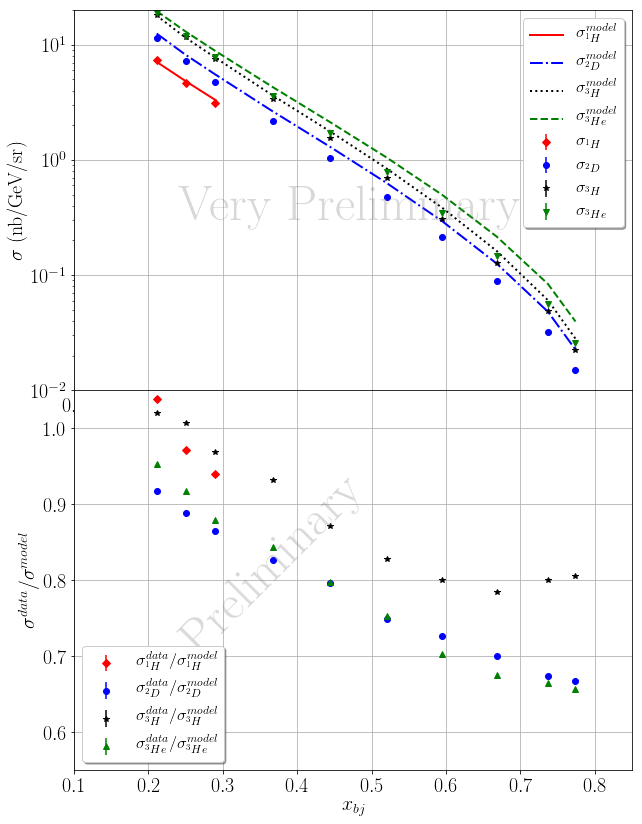

In [28]:
## Plot XS##########{{{
f1, ax = plt.subplots(2, 1, sharex=False, figsize=(10,12))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.)
#plt.grid()

#######  Subplot for Pi+ Mulplicity
axis = ax[0]
axis.errorbar(Xbj_avg, XS_H1, yerr=Err_H1/100.*XS_H1,  fmt='D', color='red',  label='$\sigma_{^{1}H}$')
axis.plot(Xbj_avg[0:3], XS_H1_MD[0:3], 'k-', color='r',linewidth=2,label='$\sigma_{^{1}H}^{model}$')

axis.errorbar(Xbj_avg, XS_D2, yerr=Err_D2/100.*XS_D2,  fmt='o', color='blue',  label='$\sigma_{^{2}D}$')
axis.plot(Xbj_avg, XS_D2_MD, 'k-.', color='b',linewidth=2,label='$\sigma_{^{2}D}^{model}$')

axis.errorbar(Xbj_avg, XS_H3, yerr=Err_H3/100.*XS_H3,  fmt='*', color='k',  label='$\sigma_{^{3}H}$')
axis.plot(Xbj_avg, XS_H3_MD, 'k:', color='k',linewidth=2,label='$\sigma_{^{3}H}^{model}$')

axis.errorbar(Xbj_avg, XS_He3,yerr=Err_He3/100.*XS_He3,fmt='v', color='g',  label='$\sigma_{^{3}He}$')
axis.plot(Xbj_avg, XS_He3_MD, 'k--', color='g',linewidth=2,label='$\sigma_{^{3}He}^{model}$')

axis.set_ylabel(r'$\sigma$ (nb/GeV/sr)')
axis.set_xlabel(r'$x_{bj}$')
axis.set_xlim(0.1,0.85)
axis.set_ylim(0.01, 20.)
axis.set_yscale('log')
axis.grid()

axis.text(0.7, 0.25, 'Very Preliminary',
         fontsize=50,rotation=0, color='gray',
         ha='right', va='bottom', alpha=0.3)


axis.legend(loc='upper right', shadow='True', fontsize='small', numpoints=1,)

#######  Subplot for Pi+ Mulplicity
axis=ax[1]
axis.errorbar(Xbj_avg, XS_H1/XS_H1_MD, yerr=Err_H1/100.*XS_H1/XS_H1_MD,  fmt='D', color='r',  label='$\sigma^{data}_{^{1}H}/\sigma^{model}_{^{1}H}$')
axis.errorbar(Xbj_avg, XS_D2/XS_D2_MD, yerr=Err_D2/100.*XS_D2/XS_D2_MD,  fmt='o', color='blue',  label='$\sigma^{data}_{^{2}D}/\sigma^{model}_{^{2}D}$')
axis.errorbar(Xbj_avg, XS_H3/XS_H3_MD, yerr=Err_H3/100.*XS_H3/XS_H3_MD,  fmt='*', color='k',  label='$\sigma^{data}_{^{3}H}/\sigma^{model}_{^{3}H}$')
axis.errorbar(Xbj_avg, XS_He3/XS_He3_MD, yerr=Err_He3/100.*XS_He3/XS_He3_MD,  fmt='^', color='g',  label='$\sigma^{data}_{^{3}He}/\sigma^{model}_{^{3}He}$')

axis.set_ylabel(r'$\sigma^{data}/\sigma^{model}$')
axis.set_xlabel(r'$x_{bj}$')
axis.set_xlim(0.1,0.85)
axis.set_ylim(0.55, 1.05)
#axis.set_yscale('log')
axis.grid()

axis.text(0.5, 0.59, 'Very Preliminary',
         fontsize=50,rotation=45, color='gray',
         ha='right', va='bottom', alpha=0.3)


axis.legend(loc='lower left', shadow='True', fontsize='small', numpoints=1,)

plt.savefig("cross_section.pdf",bbox_inches='tight')

# Plotting Ratios

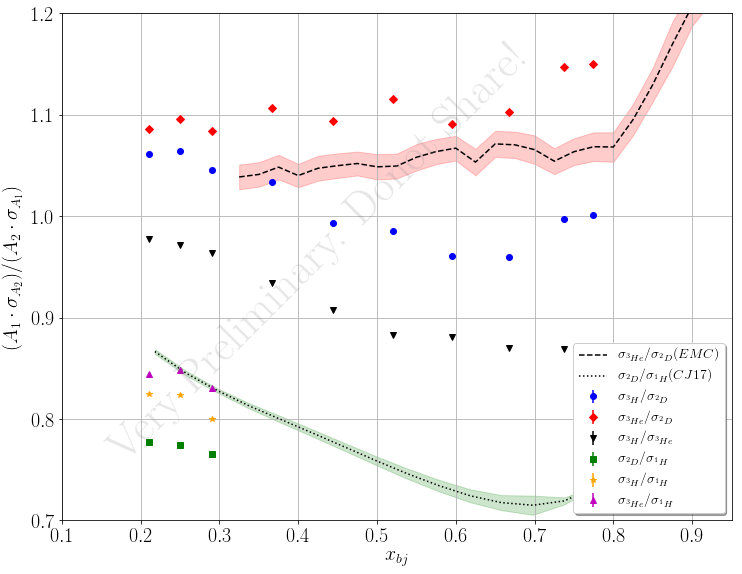

In [30]:
## Plot GEn##########{{{
f1, axis = plt.subplots(1, 1, sharex=False, figsize=(12,8))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.5)
#plt.grid()

#######  Subplot for Pi+ Mulplicity
axis.errorbar(Xbj_avg, R_H3_D2,  yerr=E_H3_D2,  fmt='o', color='blue',  label='$\sigma_{^{3}H}/\sigma_{^{2}D}$')
axis.errorbar(Xbj_avg, R_He3_D2, yerr=E_He3_D2,  fmt='D', color='r',  label='$\sigma_{^{3}He}/\sigma_{^{2}D}$')
axis.errorbar(Xbj_avg, R_H3_He3, yerr=E_H3_He3,  fmt='v', color='k',  label='$\sigma_{^{3}H}/\sigma_{^{3}He}$')

#axis.plot(Xbj, R_H3_D2_MD,  'k-', color='blue',  label='$\sigma_{^{3}H}/\sigma_{^{2}D}(F2ALLM)$')
#axis.plot(Xbj, R_He3_D2_MD, 'k--', color='r',  label='$\sigma_{^{3}He}/\sigma_{^{2}D}(F2ALLM)$')
#axis.plot(Xbj, R_H3_He3_MD,'k-.', color='k',  label='$\sigma_{^{3}H}/\sigma_{^{3}He}(F2ALLM)$')

axis.plot(x_emc, r_he3_d2_emc, 'k--', color='k',  label='$\sigma_{^{3}He}/\sigma_{^{2}D}(EMC)$')
axis.fill_between(x_emc, r_he3_d2_emc-e_he3_d2_emc, r_he3_d2_emc+e_he3_d2_emc,color='r',alpha=0.2)

axis.errorbar(Xbj_avg, R_D2_H1,  yerr=E_D2_H1,  fmt='s', color='g',  label='$\sigma_{^{2}D}/\sigma_{^{1}H}$')
axis.errorbar(Xbj_avg, R_H3_H1,  yerr=E_H3_H1,  fmt='*', color='orange',  label='$\sigma_{^{3}H}/\sigma_{^{1}H}$')
axis.errorbar(Xbj_avg, R_He3_H1, yerr=E_He3_H1,  fmt='^', color='m',  label='$\sigma_{^{3}He}/\sigma_{^{1}H}$')

#axis.plot(Xbj[0:3], R_D2_H1_MD[0:3],  'k-', color='g',  label='$\sigma_{^{2}D}/\sigma_{^{1}H}(F2ALLM)$')
#axis.plot(Xbj[0:3], R_H3_H1_MD[0:3],  'k--', color='orange',  label='$\sigma_{^{3}H}/\sigma_{^{1}H(F2ALLM)}$')
#axis.plot(Xbj[0:3], R_He3_H1_MD[0:3], 'k-.', color='m',  label='$\sigma_{^{3}He}/\sigma_{^{1}H(F2ALLM)}$')

axis.plot(x_cj, r_d2_h1_cj,  'k:', color='k',  label='$\sigma_{^{2}D}/\sigma_{^{1}H}(CJ17)$')
axis.fill_between(x_cj, r_d2_h1_cj-e_d2_h1_cj, r_d2_h1_cj+e_d2_h1_cj,color='g',alpha=0.2)

axis.set_ylabel(r'$ (A_{1} \cdot \sigma_{A_2} )/ (A_{2} \cdot \sigma_{A_1})$')
axis.set_xlabel(r'$x_{bj}$')
axis.set_xlim(0.1,0.95)
axis.set_ylim(0.7, 1.2)
axis.grid()


axis.text(0.7, 0.75, 'Very Preliminary. Donot Share!',
         fontsize=45,rotation=45, color='gray',
         ha='right', va='bottom', alpha=0.2)


axis.legend(loc='best', shadow='True', fontsize='x-small', numpoints=1,)
plt.savefig("ratio.pdf",bbox_inches='tight')